# 第4课 · 三个旋钮驯服一切声音——正弦波（sine wave）的频率、振幅（amplitude）与相位（phase，φ）

**学习目标**
1. 掌握 `A · sin(2πft + φ)` 的三个参数各控制什么
2. 实现 `sinusoid(t, A, f, phi)` 并用 assert 验证
3. 理解频率叠加：和弦（chord） = 多个正弦波相加
4. 为 L05（复数，complex number）和 L06（欧拉公式，Euler's formula）打好基础

**Aurora 连接（先记一句）**：仓库里的正弦生成与本课公式**同构**，但接口不同（细节见练习后的 🔗 格）。  
L37 的 DFT 会把任意信号拆成正弦波之和——拆开后的「原子」就是本节的 `sinusoid`。

**来自 L03 的记忆**：谱图（spectrogram）上的每条水平亮线，对应的就是一个特定频率的正弦波。
本课让你亲手控制那条线的位置（频率）、亮度（振幅）和起始角度（相位）。

← **上一课**　[L03 · 谱图直觉](../0_foundation/L03_spectrogram.ipynb)

> 上节课学习了 **谱图直觉**：在学 FFT 之前先读懂时频图的三个轴。  
> 本课将探讨 **正弦波三要素**。

## 本课剧情：三个旋钮控制一切

想象一个收音机调台器。它有三个旋钮：

- **音量旋钮**（振幅 A）：拧大 → 声音变响；拧小 → 变轻。范围从 0 到正无穷。
- **频率旋钮**（频率 f）：拧大 → 声调变高（像女高音）；拧小 → 变低（像低音炮）。
- **时间偏移旋钮**（相位 φ）：整段声音往前或往后移动一点，起点不再是波峰，而是中间的某个位置。

一个正弦波完全由这三个旋钮决定：

| 旋钮 | 符号 | 物理意义 | 谱图上的效果 |
|---|---|---|---|
| 音量 | A（振幅） | 多响 → 波峰高度 | 颜色更亮 |
| 频率 | f（Hz）| 多快 → 单位时间几个周期 | 亮线位置更高 |
| 相位 | φ（rad）| 起点在哪 → 波从哪里开始 | 谱图不变，波形水平移 |

公式：`x(t) = A · sin(2π·f·t + φ)`

本课你将实现 `sinusoid(t, A, f, phi)`——整个 Aurora DSP 管线的基础构件之一。

## 1. sin 与 cos：同一个圆的两个侧面

有没有想过：为什么 sin 和 cos 长得这么像，却不完全一样？

把一个点放在单位圆上，让它匀速逆时针转。此刻：
- **cos(θ)** = 它在 x 轴（水平方向）上的"影子"
- **sin(θ)** = 它在 y 轴（垂直方向）上的"影子"

cos 超前 sin 恰好 π/2（90°）。也就是说：

```
cos(θ) = sin(θ + π/2)
```

两个函数，同一个旋转，不同的投影方向。后面复数（L05）会把这两个影子打包成一个数——那时候你会发现 Euler 公式 `e^{iθ} = cos θ + i·sin θ` 正好描述了这个旋转点。

> 📌 读到这里如果有两个疑问——"那个圆在哪？我想看图"和""超前"是加 π/2 还是曲线往左移，到底哪边？"——别急，下面第二格代码会把单位圆和影子真的画出来，并把"超前"的三种说法一次对齐。先往下走。

## 实验入口：角度、坐标和旋转

sin 和 cos 描述同一个圆周运动的两个分量：cos 比 sin 超前四分之一个周期。观察两条曲线的峰值、零点、谷值的位置关系，确认 cos(0)=1 而 sin(0)=0。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


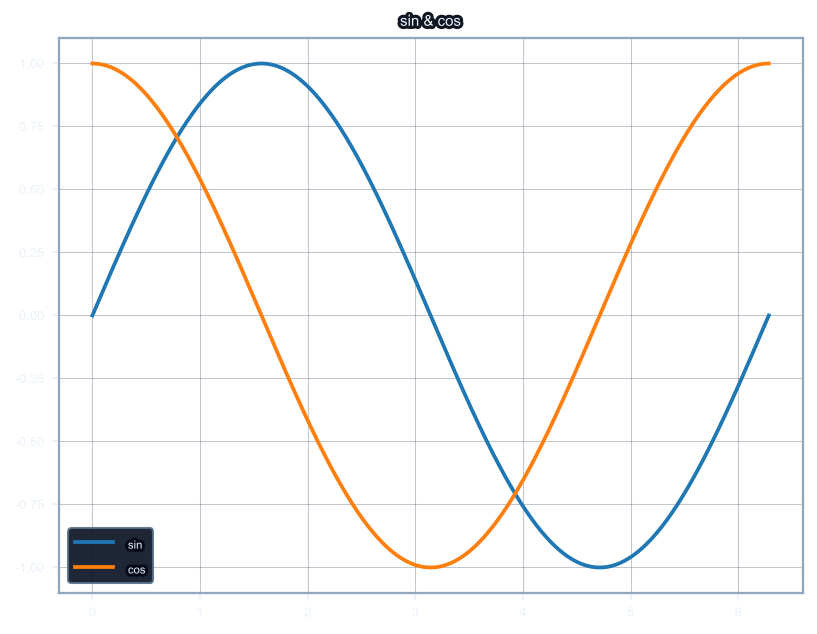

In [2]:
import numpy as np, matplotlib.pyplot as plt
t = np.linspace(0, 2*np.pi, 400)
plt.plot(t, np.sin(t), label='sin')
plt.plot(t, np.cos(t), label='cos')
plt.legend(); plt.title('sin & cos'); plt.grid(True, alpha=.3); plt.show()

### 补一张图：那个"圆"到底在哪？"超前"到底往哪边？

上面那张图只有两条曲线，第 1 节说的"单位圆上转动的点"还没露过面。下面这格代码就把它画出来：左边是圆和点，两条虚线是点分别落到 x 轴、y 轴上的"影子"；右边是熟悉的 sin/cos 曲线。两张图说的是**同一件事**——右图的曲线，就是左图两个影子随角度 θ 展开的记录。

再解决一个容易打架的问题："cos 超前 sin 恰好 π/2"到底是什么意思？公式里写 `cos(θ) = sin(θ + π/2)` 是**加号**，可图上 cos 的峰却在 sin 的峰**左边**——到底哪边算"超前"？

其实这是同一件事的三种说法，我们把它们对齐：

1. **事件说**：把"到达峰值"看成一件事。cos 在 θ=0 就到峰了，sin 要等到 θ=π/2 才到。同一件事，cos **更早**发生——这就是"超前"。
2. **图形说**：更早发生 = 整条曲线上所有事件都提前 = 曲线整体**向左移** π/2。所以 cos 的峰在 sin 的峰左边，一点不矛盾。
3. **公式说**：曲线左移 π/2，翻译成自变量就是"θ 处的 cos 值 = sin 提前跑到 θ+π/2 处的值"，即 `cos(θ) = sin(θ + π/2)`。加号加在**括号里的自变量**上，效果是曲线**往左**移——这是初学最容易记反的一点，可以用 θ=0 代入检查：`sin(0 + π/2) = 1 = cos(0)`，对上了。

一句话总结：**超前 = 事件更早发生 = 曲线左移 = 自变量加 π/2**。四个说法指同一个 π/2。

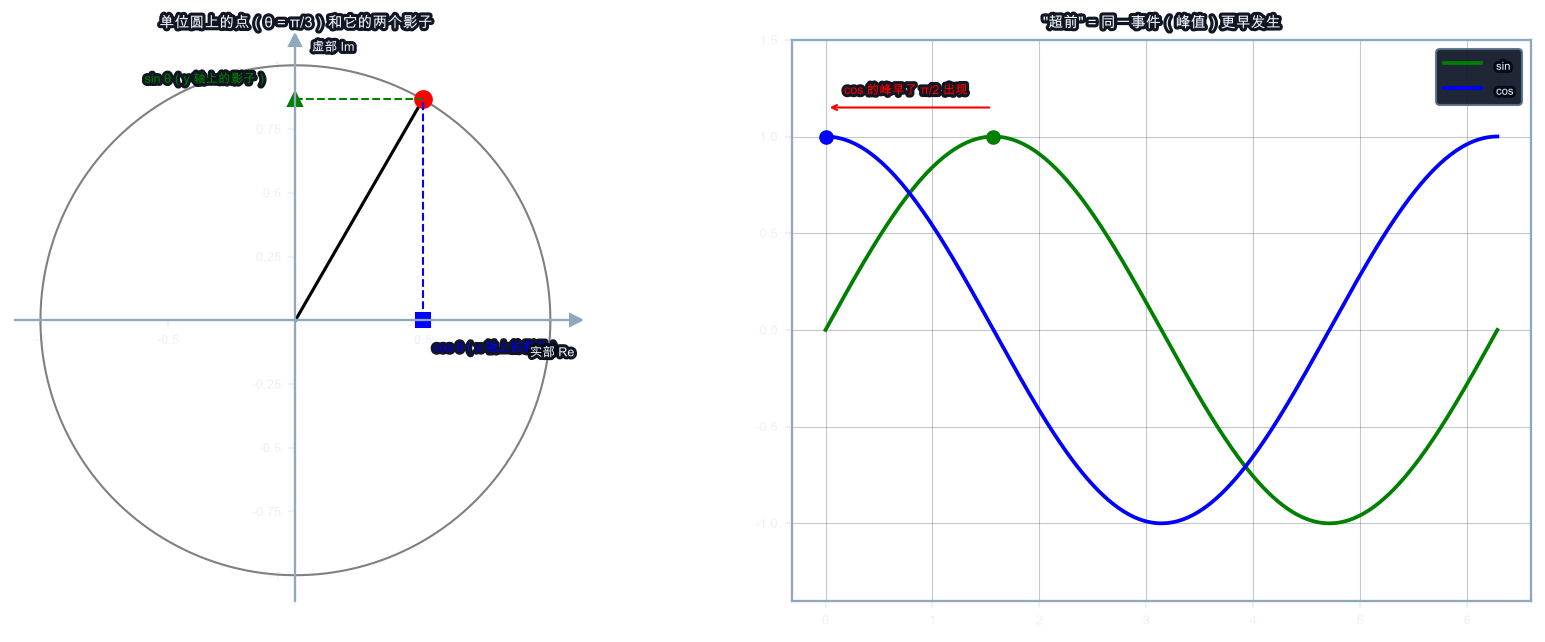

In [3]:
# 把"影子"真的画出来：左图是单位圆和转动的点，右图是两条投影随角度展开的曲线
import numpy as np
import matplotlib.pyplot as plt

theta = np.pi / 3            # 举个例子：点转到 60° 的位置（你可以改成别的角度重跑）
circle = np.linspace(0, 2*np.pi, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# ---- 左图：单位圆 + 转动的点 + 两条"影子"虚线 ----
ax1.plot(np.cos(circle), np.sin(circle), color='gray', lw=1)   # 圆本身
x0, y0 = np.cos(theta), np.sin(theta)
ax1.plot([0, x0], [0, y0], 'k-', lw=1.5)                       # 从圆心指向点的半径
ax1.plot(x0, y0, 'ro', ms=8)                                   # 转动的点
ax1.plot([x0, x0], [0, y0], 'b--', lw=1)                       # 竖直虚线：点垂直落到 x 轴
ax1.plot([0, x0], [y0, y0], 'g--', lw=1)                       # 水平虚线：点水平落到 y 轴
ax1.plot(x0, 0, 'bs', ms=7)
ax1.annotate('cos θ（x 轴上的影子）', (x0, 0), textcoords='offset points',
             xytext=(5, -15), color='b')
ax1.plot(0, y0, 'g^', ms=7)
ax1.annotate('sin θ（y 轴上的影子）', (0, y0), textcoords='offset points',
             xytext=(-10, 8), color='g', ha='right')
ax1.axhline(0, color='gray', lw=.5); ax1.axvline(0, color='gray', lw=.5)
ax1.set_aspect('equal'); ax1.set_title('单位圆上的点（θ = π/3）和它的两个影子')

# ---- 右图：sin/cos 曲线，用箭头标出"同一个峰，cos 早了 π/2 出现" ----
tt = np.linspace(0, 2*np.pi, 400)
ax2.plot(tt, np.sin(tt), 'g', label='sin')
ax2.plot(tt, np.cos(tt), 'b', label='cos')
ax2.plot(0, 1, 'bo')          # cos 的峰：θ=0 就到了
ax2.plot(np.pi/2, 1, 'go')    # sin 的峰：θ=π/2 才到
ax2.annotate('', xy=(0, 1.15), xytext=(np.pi/2, 1.15),
             arrowprops=dict(arrowstyle='->', color='r'))
ax2.text(np.pi/4, 1.22, 'cos 的峰早了 π/2 出现', color='r', ha='center')
ax2.set_ylim(-1.4, 1.5); ax2.legend(); ax2.grid(alpha=.3)
ax2.set_title('"超前" = 同一事件（峰值）更早发生')
plt.tight_layout(); plt.show()

## 动手观察：四个特殊角度

0、π/2、π、3π/2 这四个角度的 cos 和 sin 值都是 0 或 ±1，可以直接心算验证。运行后比对 `z.real` 和 `z.imag`，确认输出与预期完全一致。

> ⚠️ **先说清楚：下面这格代码借用了两件"下节课的道具"，你没有漏学任何东西。**
>
> 1. **`1j` 是什么？** 这是 Python 表示"虚数单位 i"的写法（工程里为区分电流用 j，Python 沿用了这个习惯；前面必须带数字，所以写 `1j` 而不是 `j`）。复数本身是 **L05** 的主角，今天不需要懂它。
> 2. **`np.exp(1j * θ)` 是什么？** 今天请把它当成一台**黑盒机器**：喂进去一个角度 θ，它同时吐出这个角度的 cos 和 sin——`z.real`（实部）就是 cos(θ)，`z.imag`（虚部）就是 sin(θ)。**为什么** e 的"虚数次方"会吐出 cos 和 sin，是 **L06 欧拉公式**要揭晓的谜底，本课完全不要求理解。
>
> 那为什么现在就让它出场？因为它正好是"单位圆上转动的点"的代码化身：一个 θ 进去，圆上那个点的两个影子一起出来。今天你只需要**用输出去核对上一节心算的 cos/sin 值**，把这台机器的"说明书"留到 L05/L06 再拆。

In [4]:
import numpy as np

angles = np.array([0, np.pi/2, np.pi, 3*np.pi/2])
z = np.exp(1j * angles)

print('角度 =', np.round(angles, 3))
print('实部 cos =', np.round(z.real, 3))
print('虚部 sin =', np.round(z.imag, 3))
print('复数 z =', np.round(z, 3))


角度 = [0.    1.571 3.142 4.712]
实部 cos = [ 1.  0. -1. -0.]
虚部 sin = [ 0.  1.  0. -1.]
复数 z = [ 1.+0.j  0.+1.j -1.+0.j -0.-1.j]


## 代码实验：遍历频率、振幅和相位

采样率（sample rate，sr） sr = 16 Hz、时长 0.5 s 只产生 8 个采样点，数字少到可以逐个检查：freq 加倍时相邻样本的最大变化幅度明显增大（f=1→2 约 1.85 倍，f=2→4 约 1.41 倍——正弦是弯的，并非精确翻倍），amplitude 加倍时输出的 min/max 同比例放大。

In [5]:
import numpy as np

sample_rate = 16
duration = 0.5
t = np.arange(round(duration * sample_rate)) / sample_rate

for freq in [1, 2, 4]:
    wave = np.sin(2 * np.pi * freq * t)
    print(f'freq={freq}Hz ->', np.round(wave, 3))

for amplitude in [0.5, 1.0, 2.0]:
    wave = amplitude * np.sin(2 * np.pi * 2 * t)
    print(f'amplitude={amplitude} -> min={wave.min():.1f}, max={wave.max():.1f}')


freq=1Hz -> [0.    0.383 0.707 0.924 1.    0.924 0.707 0.383]
freq=2Hz -> [ 0.     0.707  1.     0.707  0.    -0.707 -1.    -0.707]
freq=4Hz -> [ 0.  1.  0. -1. -0.  1.  0. -1.]
amplitude=0.5 -> min=-0.5, max=0.5
amplitude=1.0 -> min=-1.0, max=1.0
amplitude=2.0 -> min=-2.0, max=2.0


### 那两个数字（1.85、1.41）到底从哪来？

上面的说明抛出了"f=1→2 约 1.85 倍，f=2→4 约 1.41 倍"，但代码只打印了波形本身，并没有算这两个倍数——不该让你自己发明步骤。下面这格补上完整的计算过程，用到一个新朋友：

- **`np.diff(wave)`**：把数组里**相邻两个数相减**，得到"每一步走了多远"。比如 `diff([0, 0.4, 0.7])` → `[0.4, 0.3]`。
- 再取绝对值的最大值，就是"相邻样本的最大变化幅度"。

运行后你会在输出里**直接看到** 1.85 和 1.41，不用再手动做差。

**为什么频率翻倍，这个"最大一步"却不是精确翻倍？** 想一个天花板：正弦的值永远在 −1 到 +1 之间，所以相邻两点的差**最多也就是 2**（从谷底 −1 一步跳到峰顶 +1），不可能无限翻倍下去。频率越高、点越稀，这个"最大一步"就越接近天花板，增长自然一次比一次慢：1.85 → 1.41 → …会越来越接近 1。这就是"正弦是弯的、并非精确翻倍"背后的真正含义——**直线段翻倍斜率就翻倍差值，但正弦被 ±1 封顶，靠近峰顶的地方变化会"饱和"**。

顺带解密：输出里 f=4 那行的样本值只剩 0、±1（每周期只采 4 个点，正好落在峰、谷、零点上），最大一步是 1.0；f=2 的最大一步是 0.707（就是 sin 45° 那个熟悉的 √2/2）。所以 1.41 ≈ 1.0/0.707 = √2——你猜它像 √2，没猜错，它就是从这些特殊角度的正弦值里长出来的，不是巧合也不是印刷错误。

In [6]:
# 把"相邻样本的最大变化幅度"真的算出来——上面说明里的 1.85 和 1.41 就来自这里
import numpy as np

sample_rate = 16
duration = 0.5
t = np.arange(round(duration * sample_rate)) / sample_rate

prev_max_step = None
for freq in [1, 2, 4]:
    wave = np.sin(2 * np.pi * freq * t)
    steps = np.diff(wave)              # diff = "相邻两数相减"：wave[1]-wave[0], wave[2]-wave[1], ...
    max_step = np.max(np.abs(steps))   # 相邻两个样本之间，最大的一步跨了多远
    line = f'freq={freq}Hz | 相邻差 = {np.round(steps, 3)} | 最大一步 = {max_step:.3f}'
    if prev_max_step is not None:
        line += f' | 是上一行的 {max_step/prev_max_step:.2f} 倍'
    print(line)
    prev_max_step = max_step

freq=1Hz | 相邻差 = [ 0.383  0.324  0.217  0.076 -0.076 -0.217 -0.324] | 最大一步 = 0.383
freq=2Hz | 相邻差 = [ 0.707  0.293 -0.293 -0.707 -0.707 -0.293  0.293] | 最大一步 = 0.707 | 是上一行的 1.85 倍
freq=4Hz | 相邻差 = [ 1. -1. -1.  1.  1. -1. -1.] | 最大一步 = 1.000 | 是上一行的 1.41 倍


## 2. 公式钉死：`x(t) = A · sin(2π·f·t + φ)`（三旋钮已在剧情格讲过）

- **A 振幅** = 多响（把 `[-1, 1]` 的输出拉伸到 `[-A, A]`）
- **f 频率** = 多高，Hz（每秒完整振荡次数，决定音高）
- **φ 相位** = 起始角度偏移，单位弧度（φ=π/2 时波形从峰值开始）

三个参数互相正交：A 只缩放幅度、f 只改振荡快慢、φ 只偏移起点——改一个不影响另外两个。  
合成复杂波形（和弦，以及以后的滤波器组各个分量）时，每个成分都能单独拧旋钮。

## 3. ✏️ 实现 `sinusoid(t, A, f, phi)`

**推理路线**：
1. `t` 是时间数组（秒），`f` 是每秒完整周期数（Hz）。一个完整周期对应 `2π` 弧度，所以时刻 `t` 处的角度是 `2π·f·t`。
2. 加上初相位（initial phase） `phi`（弧度），得到完整角度序列 `2π·f·t + phi`。
3. `np.sin(...)` 把角度映射到 `[-1, 1]`；乘以 `A` 把值域扩展到 `[-A, A]`。注意顺序：先算角度，再一次性乘 A，避免多次标量乘法。

**参考输入输出**：`A=2, f=1, phi=0, t=[0, 0.25, 0.5, 0.75]` → `[0, 2, 0, -2]`（一个周期的四个采样点）

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 写代码前，先把变量表补完整

写 `sinusoid` 前明确三件事：
- 输入：`t`（时间数组）、`A`（振幅）、`f`（频率 Hz）、`phi`（初相位，默认 0）
- 关键步骤：计算相位序列 `2π·f·t + phi`，乘以 A
- 返回：与 `t` 同形状的浮点数组，值域在 `[-A, A]`

In [7]:
def sinusoid(t, A, f, phi=0.0):
    # ✏️ TODO: 返回正弦波
    raise NotImplementedError("TODO: 实现 sinusoid(t, A, f, phi)")


In [8]:
import numpy as np
t = np.linspace(0, 1, 8, endpoint=False)
try:
    y = sinusoid(t, 2.0, 1.0, 0.0)
    assert np.allclose(y, 2*np.sin(2*np.pi*1.0*t)), '应等于 2·sin(2πt)'
    # 额外检验：phi=π/2 时应等于 cos
    y_cos = sinusoid(t, 1.0, 1.0, np.pi/2)
    assert np.allclose(y_cos, np.cos(2*np.pi*t), atol=1e-10), 'phi=π/2 时应等于 cos'
    print('✅ 通过：你能造任意振幅/频率/相位的正弦波了。')
except (NotImplementedError, TypeError):
    print('⚠️ sinusoid() 还未实现，请先完成上方 TODO 再运行本格。')


⚠️ sinusoid() 还未实现，请先完成上方 TODO 再运行本格。


**🔗 Aurora 连接**：`aurora.audio.sine`（见 `src/aurora/audio/io.py`）采用同一个公式，但接口不同——它接受 `freq, duration, sample_rate` 而非时间数组 `t`，且不含 `phi` 参数。你将在 L33 实现完全对齐的 `my_sine`。下一课进入复数——FFT 的输出类型。

### 预告：下面这格要"数波形穿过零线的次数"——先认识三位新朋友

接下来我们换一种验证频率的思路：**不看波形长什么样，而是数它穿过零线（横轴）多少次**。直觉是：频率越高，波上下摆动越勤，穿过零线自然越多次。

但"数穿越"这件事代码怎么写？下面那格用了一行 `np.sum(np.diff(np.signbit(x)) != 0)`，一口气出现三个新面孔。先用一个 4 个数的小例子把它拆开——假设 `x = [0.5, -0.2, -0.7, 0.3]`（穿过零线 2 次：一次向下、一次向上）：

1. **`np.signbit(x)`**："这个数是负的吗？"逐个回答，得到 `[False, True, True, False]`（False=非负，True=负）。
2. **`np.diff(...)`**：老朋友了，"相邻两个相减"。相邻两个答案**一样**（没变号）差是 0；**不一样**（变号了，说明波从零线上方跑到了下方，或反过来）差不是 0。
3. **`np.sum(... != 0)`**：`!= 0` 把"变号处"标成 True；对 True/False 求和时，True 当 1、False 当 0——加起来就是**变号了几次**，即穿过零线几次。本例得 2，正确。

一句话：**变号的次数 = 穿过零线的次数**。先带着"理论上 f Hz 的波一秒该穿零约 2f 次"这个预期去跑下面的代码，看看数出来的数字和预期差在哪——差的那一点正是下一段要解释的。

In [9]:
sr = 32
duration = 1.0
t = np.arange(round(duration * sr)) / sr

for freq in [1, 2, 4, 8]:
    x = np.sin(2*np.pi*freq*t)
    zero_crossings = np.sum(np.diff(np.signbit(x)) != 0)
    print(f'freq={freq:>2}Hz | 前8点={np.round(x[:8], 2)} | 过零次数≈{zero_crossings}')


freq= 1Hz | 前8点=[0.   0.2  0.38 0.56 0.71 0.83 0.92 0.98] | 过零次数≈1
freq= 2Hz | 前8点=[0.   0.38 0.71 0.92 1.   0.92 0.71 0.38] | 过零次数≈3
freq= 4Hz | 前8点=[ 0.    0.71  1.    0.71  0.   -0.71 -1.   -0.71] | 过零次数≈7
freq= 8Hz | 前8点=[ 0.  1.  0. -1. -0.  1.  0. -1.] | 过零次数≈15


## 参数实验：只改一个旋钮

把 `f` 从 1 改到 4，观察相同 `t` 范围内过零（zero crossing）次数从 1 次涨到 7 次——规律约为 2f−1（f=1,2,4,8 对应 1,3,7,15），频率翻倍时过零次数大约翻倍，并不是简单的 4 倍正比。再把 `phi` 改到 `np.pi/2`，确认波形从余弦形状（先到峰值）开始。

### 为什么是 2f−1，而不是直觉里的 2f？那个"−1"去哪了？

你的直觉是对的：f Hz 的正弦一秒有 f 个完整周期，每个周期**向下穿一次、向上穿一次**零线，理论上应该穿 **2f 次**。代码却总是数出 2f−1——每次恰好少 1。少的那一次不是玄学，拿 f=1 逐个对：

- sin(2πt) 在一秒内的零点在 **t = 0、0.5、1.0** 三个位置。
- **t = 0 那个零数不到**：它是第一个样本，前面没有样本可以和它比较"变没变号"，所以"从这里出发"不算一次穿越（波是从零**出发**，不是**穿过**零）。
- **t = 1.0 那次穿越发生在窗口外**：`t = np.arange(32)/32` 的最后一个样本是 t = 31/32 ≈ 0.969，采样窗口是 [0, 1)，**不含 1.0**。波确实会在 t=1.0 再穿一次零，但那已经是"下一秒"的事，这一秒的数组里看不到。
- 剩下真正被数到的只有 t = 0.5 那一次 → **1 次 = 2×1 − 1**。✓

一般规律：f Hz 时零点在 t = 0, 1/(2f), 2/(2f), …, 1.0，掐头（起点不算穿越）去尾（1.0 在窗口外），剩 **2f−1** 次。所以"−1"是**数数方式和采样窗口边界**造成的，不是波本身少振了一下。

### 那句"并不是简单的 4 倍正比"翻译成人话

原句想否定的是这样一种误读："f 从 1 变 4（×4），过零次数也该正好 ×4，即 1×4=4 次"——实际数出来是 7 次。直白版本是：**理论过零次数 2f 才是正比于 f 的**（f 翻倍它翻倍，f×4 它×4）；代码数出的 2f−1 只是每次恒定少 1，所以从小的 f 看比值会显得"不正比"（1→3 是 3 倍，1→7 是 7 倍），f 越大这个 −1 越无关紧要，比值就越接近理论的正比关系。规律没变，只是被"−1"这个零头干扰了。

### 动手改 phi

上面那格代码里其实没有 `phi` 这个变量（它固定用 `np.sin(2πft)`），想改也没处下手。下面补一格**真的带 phi 旋钮**的版本，还会把每个过零点用红叉标在图上，让"数出来的次数"看得见、摸得着。试着把 `f` 改成 2、4，再把 `phi` 改成 `np.pi/2`，逐一验证上面的解释。

> 🎁 小彩蛋：把 `phi` 改成 `np.pi/2` 后（f=1），零点从 0、0.5、1.0 挪到了 0.25、0.75——**不再压在窗口边界上**，这回你会数到完整的 2f = 2 次！这正好反过来证明了"−1 是边界造成的，不是波本身的问题"。

f=1 Hz, phi=0.00 -> 过零次数 = 1（理论 2f = 2，差值来历见上方"−1 去哪了"）


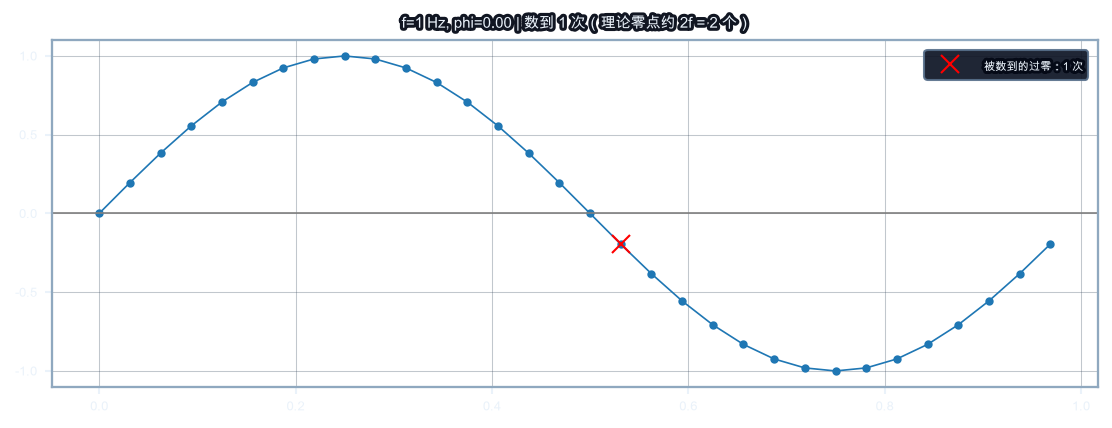

In [10]:
# 带 phi 旋钮的过零计数器：改 f 和 phi，红叉会标出每个被数到的过零点
import numpy as np
import matplotlib.pyplot as plt

sr = 32
duration = 1.0
t = np.arange(round(duration * sr)) / sr

f   = 1          # ← 试着改成 2、4、8
phi = 0.0        # ← 再试着改成 np.pi/2：波形从峰值开始（变成 cos 的形状）

x = np.sin(2 * np.pi * f * t + phi)

is_negative  = np.signbit(x)              # 每个样本是不是负数 → True/False 数组
sign_changed = np.diff(is_negative) != 0  # 相邻两个答案不一样的地方 = 变号 = 穿过零线
crossings    = np.sum(sign_changed)       # True 当 1、False 当 0，加起来就是穿越次数

plt.figure(figsize=(9, 3))
plt.plot(t, x, '.-', lw=.8)
plt.axhline(0, color='gray', lw=.8)
cross_idx = np.where(sign_changed)[0]     # 变号发生在哪几个位置
plt.plot(t[cross_idx + 1], x[cross_idx + 1], 'rx', ms=9, label=f'被数到的过零：{crossings} 次')
plt.title(f'f={f} Hz, phi={phi:.2f} | 数到 {crossings} 次（理论零点约 2f = {2*f} 个）')
plt.legend(); plt.grid(alpha=.3); plt.show()

print(f'f={f} Hz, phi={phi:.2f} -> 过零次数 = {crossings}（理论 2f = {2*f}，差值来历见上方"−1 去哪了"）')

## 参数实验：和弦 = 多个正弦波相加

任何复杂声音都可以分解成正弦波之和（这正是 Fourier 分析的核心思想）。
反过来，把多个不同频率的 `sinusoid` 加在一起，就能合成和弦。

> ⚠️ **先打预防针：下面这张图的标签是真的，形状是"假象"。**
>
> 如果你用本课白板挑战问 3 的公式（每周期采样点 = sr/f）去自查下面的代码，会算出 200/261.6 ≈ **0.76 个点/周期**——连一个周期分一个点都不够！如果你已经算过并因此起了疑心：**恭喜，你的检验完全正确，教材的图确实"翻车"了**，而且是故意留给你看的一课。
>
> 采样点太稀时会发生一种叫**混叠（aliasing）**的现象：真实的高频波"漏"过了稀疏的采样点，点连出来的曲线看起来像一条**低得多的假频率**。可以类比电影里的马车轮：轮子转得太快、相机每秒拍的帧数不够时，轮子看起来在慢转甚至倒转。具体到这格代码（sr=200）：
>
> - 261.6 Hz 会伪装成约 **61.6 Hz**（261.6 − 200）
> - 329.6 Hz 会伪装成约 **70.4 Hz**（400 − 329.6）
> - 392.0 Hz 会伪装成约 **8 Hz**（400 − 392）——所以那条"G4"看起来是一条一秒只摆 8 下的慢波
>
> 想让波形不撒谎，经验法则是**采样率至少要超过信号最高频率的 2 倍**（这叫奈奎斯特/Nyquist 条件，**L34 aliasing** 会用实验讲清为什么；L07 是傅里叶叠加直觉，不是采样定理专课）。同理，结尾那句"DFT 把和弦分解回 C4/E4/G4"在 sr=200 下也做不到——DFT 只能看到三个伪装后的假频率。
>
> 那为什么还保留这格 sr=200 的代码？因为"叠加出和弦"的**思想**（几条波逐点相加）它演示得没错，而且它是一个绝佳的反面教材。先跑它、看看假象长什么样，紧接着下一格我们把 sr 提到 8000，看真正的 C4/E4/G4。

In [11]:
import numpy as np
import matplotlib.pyplot as plt

sr, dur = 200, 1.0
t = np.arange(round(dur * sr)) / sr

try:
    # C 大调和弦：C4 + E4 + G4
    c4 = sinusoid(t, A=1.0, f=261.6)
    e4 = sinusoid(t, A=0.8, f=329.6)
    g4 = sinusoid(t, A=0.6, f=392.0)
    chord = (c4 + e4 + g4) / 3.0  # 除以 3 防止三个振幅叠加后超出 [-1,1] 范围

    fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)
    for ax, sig, label in zip(axes,
            [c4, e4, g4, chord],
            ['C4 (261.6 Hz)', 'E4 (329.6 Hz)', 'G4 (392.0 Hz)', '和弦（三者叠加）']):
        ax.plot(t, sig, lw=0.8)
        ax.set_ylabel(label, fontsize=8); ax.set_ylim(-1.4, 1.4); ax.grid(alpha=0.3)
    axes[-1].set_xlabel('时间 (s)')
    fig.suptitle('三个正弦波 → 叠加成和弦')
    plt.tight_layout(); plt.show()
    print('DFT 的任务就是从「和弦」这条曲线，分解回 C4/E4/G4 三条。')
except (NotImplementedError, TypeError):
    print('⚠️ 先完成上方 sinusoid() 练习再运行本格（和弦演示需要你的实现）。')


⚠️ 先完成上方 sinusoid() 练习再运行本格（和弦演示需要你的实现）。


### 修好它：足够高的采样率下，和弦长什么样

上面 sr=200 的图看完了假象，现在按"采样率 > 2 × 最高频率"的经验法则把 sr 提到 **8000 Hz**（8000 > 2 × 392，绰绰有余）。两个小变化值得注意：

- **只画前 20 毫秒**。261.6 Hz 一秒有 261 个周期，画满 1 秒所有波挤成一条实心带，什么也看不出；截取 20 ms，每条波只有 5~8 个周期，形状一目了然。
- **每张小图右上角标了"应有几个周期"**（频率 × 0.02 秒）。你可以直接在图上数波峰核对——这次用白板问 3 的公式自查，教材能通过检验了。

In [12]:
# 修好它：把采样率提到 8000 Hz，看真正的 C4/E4/G4
import numpy as np
import matplotlib.pyplot as plt

sr_hi = 8000                  # 每周期采样点：8000/261.6 ≈ 30.6 个——这回公式自查能通过了
dur_hi = 0.02                 # 只画前 20 毫秒：261.6 Hz 一秒有 261 个周期，画满 1 秒会挤成一团
t_hi = np.arange(round(dur_hi * sr_hi)) / sr_hi

try:
    c4 = sinusoid(t_hi, A=1.0, f=261.6)
    e4 = sinusoid(t_hi, A=0.8, f=329.6)
    g4 = sinusoid(t_hi, A=0.6, f=392.0)
    chord = (c4 + e4 + g4) / 3.0

    fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)
    for ax, sig, label, f_true in zip(axes,
            [c4, e4, g4, chord],
            ['C4 (261.6 Hz)', 'E4 (329.6 Hz)', 'G4 (392.0 Hz)', '和弦（三者叠加）'],
            [261.6, 329.6, 392.0, None]):
        ax.plot(t_hi * 1000, sig, lw=1.0)
        ax.set_ylabel(label, fontsize=8); ax.set_ylim(-1.4, 1.4); ax.grid(alpha=0.3)
        if f_true:
            # 20 ms 内应有 f×0.02 个周期，可以直接在图上数出来核对
            ax.set_title(f'20 ms 内应有 {f_true * 0.02:.1f} 个周期——数数看', fontsize=8, loc='right')
    axes[-1].set_xlabel('时间 (ms)')
    fig.suptitle('sr = 8000 Hz：这才是 C4/E4/G4 真实的样子（只画前 20 ms）')
    plt.tight_layout(); plt.show()
    print(f'自查通过：每周期采样点 = 8000/261.6 ≈ {8000/261.6:.1f} 个（远大于 2，波形可信）。')
    print('在这个采样率下，DFT 才能真正把和弦分解回 C4/E4/G4 三条亮线。')
except (NotImplementedError, TypeError):
    print('⚠️ 先完成上方 sinusoid() 练习再运行本格。')

⚠️ 先完成上方 sinusoid() 练习再运行本格。


In [13]:
# 小检查：同一个角度，同时看 cos、sin、复数
# （再次借用 L05 的道具：np.exp(1j*θ) 是那台"喂角度、同时吐出 cos 和 sin"的黑盒机器，
#   z.real = cos(θ)，z.imag = sin(θ)。原理 L06 欧拉公式揭晓，这里照旧当黑盒用即可。）
import numpy as np

for theta in [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]:
    z = np.exp(1j * theta)
    print(f'theta={theta:5.2f} -> cos={z.real:+.1f}, sin={z.imag:+.1f}, complex={z.real:+.1f}{z.imag:+.1f}j')

theta= 0.00 -> cos=+1.0, sin=+0.0, complex=+1.0+0.0j
theta= 1.57 -> cos=+0.0, sin=+1.0, complex=+0.0+1.0j
theta= 3.14 -> cos=-1.0, sin=+0.0, complex=-1.0+0.0j
theta= 4.71 -> cos=-0.0, sin=-1.0, complex=-0.0-1.0j
theta= 6.28 -> cos=+1.0, sin=-0.0, complex=+1.0-0.0j


## 本课收束

现在你能用 `sinusoid(t, A, f, phi)` 生成任意振幅、频率、相位的正弦波，
并用 `assert np.allclose` 验证数值是否正确。

**和弦 = 正弦波叠加**：两个不同频率的 `sinusoid` 相加，谱图上就出现两条亮线——
这正是 DFT 反问题的直觉：「给定叠加的波形，分解出每条线的位置和高度」。

**下一课 L05**：复数的模与相位——给每个频率发一张身份证，读出模与相位，这是 FFT 的母语。
FFT 的每个输出频点（frequency bin）都是一个复数：**模 = 该频率有多响，相位 = 时间对齐信息**。
今天的 A 和 φ，就对应那个复数的模和相位——**严格对应关系下一课 L05 动手读**，今天先建立「两个量、一张身份证」的画面即可。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：三要素手算（目标 8 分钟）

盖上屏幕，纸上回答：

**参数**：A = 2，f = 440 Hz，φ = π/4，sr = 8000 Hz

**问 1**：写出 `x(t)` 的完整公式（用数字代入，不简化）。

**问 2**：`t = 1/880` 秒时，x 的精确值是多少？
提示：`sin(2π·440·(1/880) + π/4)` = `sin(π + π/4)` = ?

> 🛟 **救生圈：忘了诱导公式怎么办？** 高中那条 **sin(π + x) = −sin(x)** 如果早忘光了，用第 1 节的单位圆现场重造一个：角度加 π 意味着点**转过半圈**，跑到圆心的正对面——两个"影子"（cos 和 sin）同时跑到反方向，所以都**变号**。于是 sin(π + π/4) = −sin(π/4) = −√2/2 ≈ −0.707。忘公式不要紧，"转半圈 → 影子变号"这幅画面比公式可靠。

**问 3**：频率 440 Hz、采样率 8000 Hz，一个周期内有多少个采样点？（不必是整数）

**问 4**：若把 φ 改为 0，x(0) 的值变成多少？（原来 φ=π/4 时 x(0) 是多少？）

推导完成后运行下面格对答案。

In [14]:
# ✏️ 对答案格
import numpy as np

A, f, phi, sr = 2.0, 440.0, np.pi/4, 8000

# 问1：公式验证（用代码验证你的公式）
t_test = np.array([0.0, 1/880, 1/440])
x_formula = A * np.sin(2 * np.pi * f * t_test + phi)
print(f"Q1 ✅  x(t) = {A} · sin(2π·{f:.0f}·t + π/4)")
print(f"       x(0)      = {x_formula[0]:.4f}")
print(f"       x(1/880)  = {x_formula[1]:.4f}")

# 问2：手算验证
t2 = 1/880
theta = 2 * np.pi * f * t2 + phi
# 2π·440·(1/880) = 2π·0.5 = π，所以 θ = π + π/4 = 5π/4
# 中间那步为什么 sin(5π/4) = -√2/2？分两小步：
#   ① 诱导公式：sin(π + x) = -sin(x)（转过半圈，影子跑到圆心对面，变号）
#      所以 sin(5π/4) = sin(π + π/4) = -sin(π/4)
#   ② 特殊角：sin(π/4) = sin(45°) = √2/2 ≈ 0.707
#   合起来：sin(5π/4) = -√2/2，再乘振幅 2 → -√2
x2_theory = 2 * np.sin(5 * np.pi / 4)  # = 2·(-√2/2) = -√2
x2_code   = A * np.sin(2 * np.pi * f * t2 + phi)
assert np.isclose(x2_code, x2_theory, atol=1e-10), f"Q2 差异: {x2_code:.6f} vs {x2_theory:.6f}"
print(f"\nQ2 ✅  x(1/880) = 2·sin(5π/4) = 2·(-√2/2) = -√2 ≈ {x2_theory:.4f}  代码值 {x2_code:.4f}")

# 问3：每周期采样点数
samples_per_cycle = sr / f
print(f"\nQ3 ✅  每周期采样点 = {sr}/{f:.0f} = {samples_per_cycle:.4f} 点/周期")

# 问4：相位为0时 x(0)
x_phi0 = A * np.sin(2 * np.pi * f * 0 + 0)    # = 0
x_phiQ = A * np.sin(2 * np.pi * f * 0 + phi)  # = 2·sin(π/4) = √2
assert np.isclose(x_phi0, 0.0, atol=1e-12)
print(f"\nQ4 ✅  φ=0 时 x(0) = {x_phi0:.4f}  φ=π/4 时 x(0) = {x_phiQ:.4f} (= √2 ≈ {np.sqrt(2):.4f})")
print("\n🎉 白板挑战通过！三要素 A / f / φ 的手算已经内化。")

Q1 ✅  x(t) = 2.0 · sin(2π·440·t + π/4)
       x(0)      = 1.4142
       x(1/880)  = -1.4142

Q2 ✅  x(1/880) = 2·sin(5π/4) = 2·(-√2/2) = -√2 ≈ -1.4142  代码值 -1.4142

Q3 ✅  每周期采样点 = 8000/440 = 18.1818 点/周期

Q4 ✅  φ=0 时 x(0) = 0.0000  φ=π/4 时 x(0) = 1.4142 (= √2 ≈ 1.4142)

🎉 白板挑战通过！三要素 A / f / φ 的手算已经内化。


In [ ]:
# ✏️ 本课自评
l04_review = {
    "sinusoid_implemented":   None,  # sinusoid 函数实现并通过断言？True/False
    "three_params_understood": None, # 能解释 A/f/φ 各自对波形的影响？True/False
    "whiteboard_passed":       None, # 白板挑战纸上推导完成？True/False
    "chord_intuition":         None, # 理解"和弦 = 多正弦波叠加"？True/False
}

unfilled = [k for k, v in l04_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l04_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L04 全部通关！进入 L05：复数几何本质')

---

→ **下一课**　[L05 · 复数的模与相位](L05_complex_numbers.ipynb)

> 下节课将学习 **复数的模与相位**：给每个频率发一张身份证——从复数读出模与相位，这是 FFT 的母语。